In [48]:
!pip install pandas scikit-learn numpy rlcmab-sampler



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


from rlcmab_sampler import sampler


# Load and Preprocess Users

In [50]:
def load_and_preprocess_users(path):
    df = pd.read_csv(path)

    # Normalize label case
    df["label"] = df["label"].str.lower()

    # Handle missing values
    df = df.ffill()

    encoders = {}

    # Encode categorical columns (except label)
    for col in df.select_dtypes(include="object").columns:
        if col != "label":
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le

    return df, encoders


In [51]:
df1 = pd.read_csv("/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv")
print(df1["label"].value_counts())

label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64


In [52]:
df1.head()

,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,...,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,...,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,...,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3
3,U7475,NaN,26615,12,500.00,30.17,0.26499,30.19441,10,195.35,...,4.2,77.0,9,9.90.20,4,21.61,22.0,X123,False,user_3
4,U6040,32.0,27958,13,500.00,65.27,0.36385,37.12153,5,439.68,...,4.6,30.0,9,1.99.38,7,7.58,52.0,S043,False,user_1


In [53]:
df2 = pd.read_csv("/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/test_users.csv")
print(df1["label"].value_counts())

label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64


In [54]:
df2.head()

,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,loyalty_index,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber
0,U4058,36.0,10000,4,500.00,2.54,0.47162,49.32668,8,229.80,...,13.0,3.0,39.0,3,5.99.65,7,7.86,26.0,X789,True
1,U1118,33.0,19607,8,1906.81,39.74,0.55219,56.42526,4,819.43,...,30.0,4.6,84.0,5,7.22.85,12,2.79,42.0,P752,True
2,U6555,51.0,21049,11,500.00,46.07,0.69961,58.88307,5,113.35,...,21.0,2.1,88.0,7,3.29.28,11,27.50,11.0,P878,False
3,U9170,58.0,25752,13,500.00,60.86,0.86843,86.15690,8,237.13,...,37.0,1.9,34.0,7,6.80.77,15,22.21,34.0,Z670,False
4,U3348,32.0,25302,12,2693.22,39.77,0.81805,84.82418,5,1491.56,...,45.0,3.0,6.0,6,9.29.14,8,11.44,0.0,M101,False


# Training Context Classifier

In [55]:
# Removed

# Context to Arm Mapping

In [56]:
context_map = {
    "user_1": 0,
    "user_2": 1,
    "user_3": 2
}

category_map = {
    "Entertainment": 0,
    "Education": 1,
    "Tech": 2,
    "Crime": 3
}

# Training and testing a randomforest classifier

In [57]:
def train_model(df):

    X = df.drop("label", axis=1)
    y = df["label"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    model = DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=15,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)

    return model, [train_acc], [val_acc]


'''def train_model(df):

    X = df.drop("label", axis=1)
    y = df["label"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Scale features (important for logistic regression)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        multi_class="auto"
    )

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)

    return model, scaler, [train_acc], [val_acc]
'''


'def train_model(df):\n\n    X = df.drop("label", axis=1)\n    y = df["label"]\n\n    X_train, X_val, y_train, y_val = train_test_split(\n        X, y,\n        test_size=0.2,\n        stratify=y,\n        random_state=42\n    )\n\n    # Scale features (important for logistic regression)\n    scaler = StandardScaler()\n    X_train = scaler.fit_transform(X_train)\n    X_val = scaler.transform(X_val)\n\n    model = LogisticRegression(\n        max_iter=1000,\n        multi_class="auto"\n    )\n\n    model.fit(X_train, y_train)\n\n    train_preds = model.predict(X_train)\n    val_preds = model.predict(X_val)\n\n    train_acc = accuracy_score(y_train, train_preds)\n    val_acc = accuracy_score(y_val, val_preds)\n\n    print("Train Accuracy:", train_acc)\n    print("Validation Accuracy:", val_acc)\n\n    return model, scaler, [train_acc], [val_acc]\n'

# Plotting charts

In [58]:
import matplotlib.pyplot as plt

def plot_training_curves(train_acc, val_acc):

    if len(train_acc) == 0 or len(val_acc) == 0:
        print("No training data to plot.")
        return

    epochs = list(range(1, len(train_acc) + 1))

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_acc, marker="o", label="Train Accuracy")
    plt.plot(epochs, val_acc, marker="o", label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Testing

In [59]:
def test_model(model, encoders, test_path):
    df_test = pd.read_csv(test_path)
    df_test.columns = df_test.columns.str.strip().str.lower()

    has_label = "label" in df_test.columns
    if has_label:
        df_test["label"] = df_test["label"].str.lower()

    # Preserve user_id for output
    user_ids = df_test["user_id"].copy() if "user_id" in df_test.columns else None

    # Drop non-feature columns
    if "user_id" in df_test.columns:
        df_test = df_test.drop("user_id", axis=1)

    # Fill missing
    df_test = df_test.ffill()

    # Encode categoricals using training encoders (handle unseen as -1)
    for col, le in encoders.items():
        if col in df_test.columns:
            def encode_val(x):
                x = str(x)
                if x in le.classes_:
                    return le.transform([x])[0]
                # Extend classes_ to include unseen label and map to last index
                le.classes_ = np.append(le.classes_, x)
                return le.transform([x])[0]
            df_test[col] = df_test[col].apply(encode_val)

    # Feature binning (same as training)
    if "income" in df_test.columns:
        df_test["income"] = pd.qcut(df_test["income"], 10, labels=False, duplicates="drop")
    if "purchase_amount" in df_test.columns:
        df_test["purchase_amount"] = pd.qcut(df_test["purchase_amount"], 10, labels=False, duplicates="drop")
    if "clicks" in df_test.columns:
        df_test["clicks"] = pd.qcut(df_test["clicks"], 10, labels=False, duplicates="drop")
    if "age" in df_test.columns:
        df_test["age"] = pd.qcut(df_test["age"], 8, labels=False, duplicates="drop")

    # Feature engineering
    if "income" in df_test.columns and "clicks" in df_test.columns:
        df_test["income_per_click"] = df_test["income"] / (df_test["clicks"] + 1)
    if "purchase_amount" in df_test.columns and "income" in df_test.columns:
        df_test["spend_ratio"] = df_test["purchase_amount"] / (df_test["income"] + 1)

    if has_label:
        X_test = df_test.drop("label", axis=1)
        y_test = df_test["label"]
        preds = model.predict(X_test)
        test_acc = accuracy_score(y_test, preds)
        print("Test Accuracy:", test_acc)
        return test_acc
    else:
        preds = model.predict(df_test)
        print("No label column found. Returning in-memory predictions.")
        results = pd.DataFrame({"user_id": user_ids, "label": preds})
        return None, results

'''def test_model(model, scaler, encoders, test_path):

    df_test = pd.read_csv(test_path)

    # Normalize labels
    df_test["label"] = df_test["label"].str.lower()

    # Drop ID column
    if "user_id" in df_test.columns:
        df_test = df_test.drop("user_id", axis=1)

    # Fill missing values
    df_test = df_test.ffill()

    # Feature binning (same as training)
    df_test["income"] = pd.qcut(df_test["income"], 10, labels=False, duplicates="drop")
    df_test["purchase_amount"] = pd.qcut(df_test["purchase_amount"], 10, labels=False, duplicates="drop")
    df_test["clicks"] = pd.qcut(df_test["clicks"], 10, labels=False, duplicates="drop")

    # Feature engineering (same as training)
    df_test["income_per_click"] = df_test["income"] / (df_test["clicks"] + 1)
    df_test["spend_ratio"] = df_test["purchase_amount"] / (df_test["income"] + 1)

    # Split features and labels
    X_test = df_test.drop("label", axis=1)
    y_test = df_test["label"]

    # Scale features
    X_test = scaler.transform(X_test)

    preds = model.predict(X_test)
    test_acc = accuracy_score(y_test, preds)

    print("Test Accuracy:", test_acc)

    return test_acc'''


'def test_model(model, scaler, encoders, test_path):\n\n    df_test = pd.read_csv(test_path)\n\n    # Normalize labels\n    df_test["label"] = df_test["label"].str.lower()\n\n    # Drop ID column\n    if "user_id" in df_test.columns:\n        df_test = df_test.drop("user_id", axis=1)\n\n    # Fill missing values\n    df_test = df_test.ffill()\n\n    # Feature binning (same as training)\n    df_test["income"] = pd.qcut(df_test["income"], 10, labels=False, duplicates="drop")\n    df_test["purchase_amount"] = pd.qcut(df_test["purchase_amount"], 10, labels=False, duplicates="drop")\n    df_test["clicks"] = pd.qcut(df_test["clicks"], 10, labels=False, duplicates="drop")\n\n    # Feature engineering (same as training)\n    df_test["income_per_click"] = df_test["income"] / (df_test["clicks"] + 1)\n    df_test["spend_ratio"] = df_test["purchase_amount"] / (df_test["income"] + 1)\n\n    # Split features and labels\n    X_test = df_test.drop("label", axis=1)\n    y_test = df_test["label"]\n\n   

# Plots

In [60]:
def plot_final_results(val_acc_history, test_acc):

    if len(val_acc_history) == 0:
        print("No validation history to plot.")
        return

    epochs = list(range(1, len(val_acc_history) + 1))

    plt.figure(figsize=(8,5))
    plt.plot(epochs, val_acc_history, marker="o", label="Validation Accuracy")

    # Draw horizontal test accuracy line
    plt.axhline(y=test_acc, linestyle="--", label=f"Test Accuracy ({test_acc:.3f})")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation vs Test Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Main flow 

In [61]:
def main():
    df, encoders = load_and_preprocess_users(
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv"
    )

    # Normalize columns
    df.columns = df.columns.str.strip().str.lower()
    df["label"] = df["label"].str.lower()

    # Drop ID
    if "user_id" in df.columns:
        df = df.drop("user_id", axis=1)

    # Fill missing
    df = df.ffill()

    # Encode any remaining object columns not handled earlier
    from sklearn.preprocessing import LabelEncoder
    for col in df.select_dtypes(include=["object"]).columns:
        if col != "label" and col not in encoders:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le

    # Feature binning
    df["income"] = pd.qcut(df["income"], 10, labels=False, duplicates="drop")
    df["purchase_amount"] = pd.qcut(df["purchase_amount"], 10, labels=False, duplicates="drop")
    df["clicks"] = pd.qcut(df["clicks"], 10, labels=False, duplicates="drop")
    df["age"] = pd.qcut(df["age"], 8, labels=False, duplicates="drop")

    # Feature engineering
    df["income_per_click"] = df["income"] / (df["clicks"] + 1)
    df["spend_ratio"] = df["purchase_amount"] / (df["income"] + 1)

    # Train
    model, train_acc, val_acc = train_model(df)
    global trained_model, bandit_users_df
    trained_model = model
    bandit_users_df = df.copy()
    plot_training_curves(train_acc, val_acc)

    # Test
    test_result = test_model(
        model,
        encoders,
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/test_users.csv"
    )

    if isinstance(test_result, tuple):
        # No labels in test: (None, predictions_df)
        test_acc, results_df = test_result
        print("No test labels available — skipping validation vs test plot.")
        print(results_df.head())
    else:
        test_acc = test_result
        plot_final_results(val_acc, test_acc)

    print("Pipeline completed successfully.")




'''def main():

    # Load training data
    df, encoders = load_and_preprocess_users(
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv"
    )

    # Normalize labels
    df["label"] = df["label"].str.lower()

    # Drop ID column
    if "user_id" in df.columns:
        df = df.drop("user_id", axis=1)

    # Fill missing values
    df = df.ffill()

    # Feature binning
    df["income"] = pd.qcut(df["income"], 10, labels=False, duplicates="drop")
    df["purchase_amount"] = pd.qcut(df["purchase_amount"], 10, labels=False, duplicates="drop")
    df["clicks"] = pd.qcut(df["clicks"], 10, labels=False, duplicates="drop")

    # Feature engineering
    df["income_per_click"] = df["income"] / (df["clicks"] + 1)
    df["spend_ratio"] = df["purchase_amount"] / (df["income"] + 1)

    # Train model
    model, scaler, train_acc, val_acc = train_model(df)

    # Plot training curves
    plot_training_curves(train_acc, val_acc)

    # Test model
    test_acc = test_model(
        model,
        scaler,
        encoders,
        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/test_users.csv"
    )

    # Plot validation vs test
    plot_final_results(val_acc, test_acc)

    print("Pipeline completed successfully.")
'''


'def main():\n\n    # Load training data\n    df, encoders = load_and_preprocess_users(\n        "/Users/yatharthnehva/Desktop/lab3-contextual-bandit/data/train_users.csv"\n    )\n\n    # Normalize labels\n    df["label"] = df["label"].str.lower()\n\n    # Drop ID column\n    if "user_id" in df.columns:\n        df = df.drop("user_id", axis=1)\n\n    # Fill missing values\n    df = df.ffill()\n\n    # Feature binning\n    df["income"] = pd.qcut(df["income"], 10, labels=False, duplicates="drop")\n    df["purchase_amount"] = pd.qcut(df["purchase_amount"], 10, labels=False, duplicates="drop")\n    df["clicks"] = pd.qcut(df["clicks"], 10, labels=False, duplicates="drop")\n\n    # Feature engineering\n    df["income_per_click"] = df["income"] / (df["clicks"] + 1)\n    df["spend_ratio"] = df["purchase_amount"] / (df["income"] + 1)\n\n    # Train model\n    model, scaler, train_acc, val_acc = train_model(df)\n\n    # Plot training curves\n    plot_training_curves(train_acc, val_acc)\n\n    # 

Train Accuracy: 0.92875
Validation Accuracy: 0.85


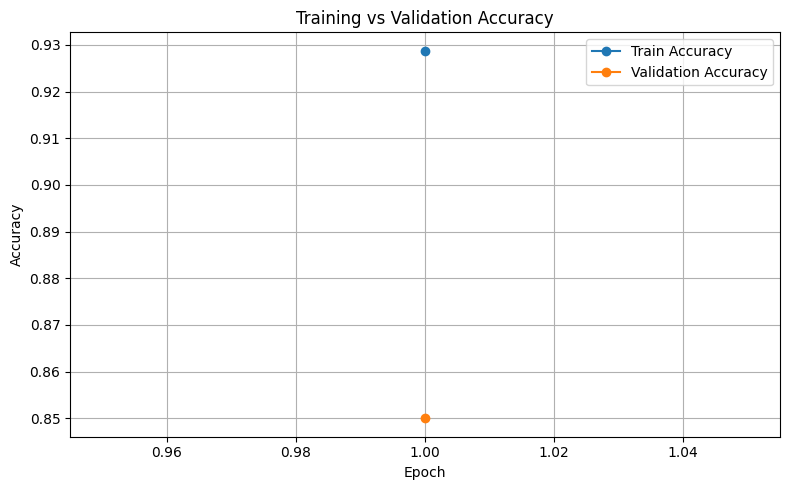

No label column found. Returning in-memory predictions.
No test labels available — skipping validation vs test plot.
  user_id   label
0   U4058  user_3
1   U1118  user_1
2   U6555  user_3
3   U9170  user_1
4   U3348  user_1
Pipeline completed successfully.


In [62]:
main()

In [63]:
from rlcmab_sampler import sampler

reward_sampler = sampler(39)


In [64]:
def get_arm_index(context_id, category_id):
    return context_id * 4 + category_id


In [65]:
import numpy as np

def initialize_bandit():
    Q = np.zeros((3, 4))      # expected reward
    N = np.zeros((3, 4))      # counts
    return Q, N


In [66]:
def epsilon_greedy(Q, N, epsilon, T=10000):

    rewards_over_time = []

    for t in range(T):

        row = bandit_users_df.sample(1)
        X_user = row.drop("label", axis=1)

        predicted_label = trained_model.predict(X_user)[0]
        context = context_map[predicted_label]


        if np.random.rand() < epsilon:
            action = np.random.randint(0, 4)
        else:
            action = np.argmax(Q[context])

        arm_index = get_arm_index(context, action)

        reward = reward_sampler.sample(arm_index)

        N[context, action] += 1
        Q[context, action] += (reward - Q[context, action]) / N[context, action]

        rewards_over_time.append(reward)

    return rewards_over_time


In [67]:
def ucb(Q, N, C, T=10000):

    rewards_over_time = []

    for t in range(1, T+1):

        row = bandit_users_df.sample(1)
        X_user = row.drop("label", axis=1)

        predicted_label = trained_model.predict(X_user)[0]
        context = context_map[predicted_label]


        ucb_values = np.zeros(4)

        for a in range(4):
            if N[context, a] == 0:
                ucb_values[a] = float("inf")
            else:
                ucb_values[a] = Q[context, a] + C * np.sqrt(np.log(t) / N[context, a])

        action = np.argmax(ucb_values)

        arm_index = get_arm_index(context, action)

        reward = reward_sampler.sample(arm_index)

        N[context, action] += 1
        Q[context, action] += (reward - Q[context, action]) / N[context, action]

        rewards_over_time.append(reward)

    return rewards_over_time


In [68]:
def softmax(Q, N, tau=1, T=10000):

    rewards_over_time = []

    for t in range(T):

        row = bandit_users_df.sample(1)
        X_user = row.drop("label", axis=1)

        predicted_label = trained_model.predict(X_user)[0]
        context = context_map[predicted_label]


        preferences = Q[context] / tau
        probs = np.exp(preferences) / np.sum(np.exp(preferences))

        action = np.random.choice(4, p=probs)

        arm_index = get_arm_index(context, action)

        reward = reward_sampler.sample(arm_index)

        N[context, action] += 1
        Q[context, action] += (reward - Q[context, action]) / N[context, action]

        rewards_over_time.append(reward)

    return rewards_over_time


In [69]:
import matplotlib.pyplot as plt

def plot_average_reward(rewards, label):

    avg_reward = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)

    plt.plot(avg_reward, label=label)


In [70]:
def run_bandit_experiments():

    T = 10000

    # Epsilon Greedy
    for eps in [0.1, 0.2, 0.3]:
        Q, N = initialize_bandit()
        rewards = epsilon_greedy(Q, N, eps, T)
        plot_average_reward(rewards, f"Epsilon={eps}")

    # UCB
    for C in [0.5, 1, 2]:
        Q, N = initialize_bandit()
        rewards = ucb(Q, N, C, T)
        plot_average_reward(rewards, f"UCB C={C}")

    # Softmax
    Q, N = initialize_bandit()
    rewards = softmax(Q, N, tau=1, T=T)
    plot_average_reward(rewards, "Softmax τ=1")

    plt.legend()
    plt.title("Average Reward vs Time")
    plt.xlabel("Steps")
    plt.ylabel("Average Reward")
    plt.show()


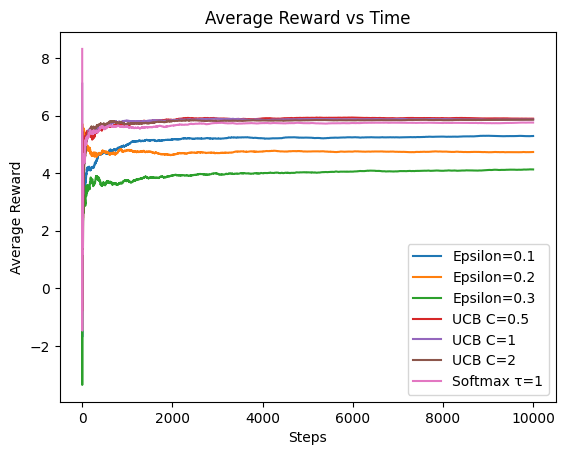

In [71]:
run_bandit_experiments()